In [3]:
# ==============================================================================
# CELL 1: IMPORTS & CONFIGURATION (MULTI-TASK LEARNING)
# ==============================================================================
import os
import random
import hashlib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW 
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef, roc_auc_score, 
    confusion_matrix, roc_curve, f1_score, precision_score, recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime
from safetensors.torch import save_file, load_file
import torch
import gc
torch.cuda.empty_cache()
gc.collect()

# --- CONFIGURATION ---
class Config:
    POSITIVE_CSV = "datasets/fusion_gene_positive_bp_information_with_class_for_modeling.txt"
    NEGATIVE_CSV = "datasets/fusion_gene_negative_bp_information_with_class_for_modeling.txt"
    
    EXTRA_POS_FASTA = "datasets/blast_validated_chimeras.fasta,datasets/cosmic_high_confidence_sequences.fna,datasets/chimeras_43466.fa"
    NEG_FASTA_CANONICAL = "datasets/false_negative_candidates.fasta"
    NEG_FASTA_SYNTHETIC = "datasets/false_positive_candidates.fasta"
    
    OUTPUT_DIR = "./hyenadna_mtl_checkpoints"
    MODEL_NAME = "LongSafari/hyenadna-small-32k-seqlen-hf"
    
    # --- MULTI-TASK LEARNING PARAMETERS ---
    MAX_LEN = 32768  
    BATCH_SIZE = 1             # Dropped to 1 to survive the FP32 FFT spike
    ACCUMULATION_STEPS = 8     # 1 * 8 = Effective batch size of 8
    
    EPOCHS = 3
    LEARNING_RATE = 1e-5
    SEED = 42
    BP_LOSS_WEIGHT = 0.5

if not os.path.exists(Config.OUTPUT_DIR):
    os.makedirs(Config.OUTPUT_DIR)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(Config.SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Setup Complete. Device: {device}")

# ==============================================================================
# CELL 2: GEOMETRIC DATA PREPARATOR & DATASET
# ==============================================================================
class DataPreparator:
    COLUMNS = ["Hgene","Hchr","Hbp","Hstrand","Tgene","Tchr","Tbp","Tstrand","5'-gene sequence (10Kb)","3'-gene sequence (10Kb)"]

    def __init__(self, config):
        self.cfg = config
        self.trans_table = str.maketrans("ATCGN", "TAGCN")

    def _trim_artifacts(self, sequence: str) -> str:
        if not isinstance(sequence, str): return ""
        return sequence.upper().strip()

    def _generate_random_dna(self, length: int) -> str:
        if length <= 0: return ""
        return "".join(random.choices("ACGT", k=length))

    def _prepare_sequence_with_bp(self, seq_5p: str, seq_3p: str, label: int, is_training=True):
        """
        Combines sequences, applies adversarial operators, and TRACKS the breakpoint index.
        Returns: (final_sequence, target_breakpoint_index)
        """
        seq_5p = self._trim_artifacts(seq_5p)
        seq_3p = self._trim_artifacts(seq_3p)
        core_seq = seq_5p + seq_3p
        core_len = len(core_seq)
        
        # 1. Establish Initial Breakpoint
        if label == 1:
            # If 3' is empty (e.g., from FASTA), assume fusion is in the dead center
            bp_idx = len(core_seq) // 2 if not seq_3p else len(seq_5p)
        else:
            bp_idx = -100 # PyTorch's default ignore_index for CrossEntropyLoss
            
        target_len = self.cfg.MAX_LEN
        
        # 2. Window Adjustment (Padding or Cropping)
        if core_len < target_len:
            needed = target_len - core_len
            pad_left = random.randint(0, needed) if is_training else needed // 2
            
            # Neutral N-padding or ACGT noise based on preference
            seq = ("N" * pad_left) + core_seq + ("N" * (needed - pad_left))
            if label == 1: bp_idx += pad_left
            
        elif core_len > target_len:
            if label == 1:
                # CRITICAL: Must crop such that the breakpoint stays inside the window
                min_start = max(0, bp_idx - target_len + 1)
                max_start = min(core_len - target_len, bp_idx)
                
                # Failsafe
                if min_start > max_start: start = (core_len - target_len) // 2
                else: start = random.randint(min_start, max_start) if is_training else (min_start + max_start) // 2
            else:
                max_start = core_len - target_len
                start = random.randint(0, max_start) if is_training else max_start // 2
                
            seq = core_seq[start : start + target_len]
            if label == 1: bp_idx -= start
        else:
            seq = core_seq

        # 3. Strand Awareness (Reverse Complement)
        if is_training and random.random() > 0.5:
            seq = seq.translate(self.trans_table)[::-1]
            if label == 1:
                bp_idx = target_len - 1 - bp_idx
                
        # 4. Circular Permutation (ONLY on negatives to avoid splitting a fusion)
        if is_training and label == 0 and random.random() > 0.8:
            if len(seq) > 200:
                k = random.randint(50, len(seq) - 50)
                seq = seq[k:] + seq[:k]
                # bp_idx remains -100

        return seq, bp_idx

    def _load_fasta(self, path: str) -> list:
        if not os.path.exists(path): return []
        seqs, curr = [], []
        with open(path, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('>'):
                    if curr: seqs.append(self._trim_artifacts("".join(curr)))
                    curr = []
                else: curr.append(line)
            if curr: seqs.append(self._trim_artifacts("".join(curr)))
        return seqs

class DNABreakpointDataset(Dataset):
    def __init__(self, sequences, labels, target_bps, tokenizer, max_len):
        self.sequences = sequences
        self.labels = labels
        self.target_bps = target_bps
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self): return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = str(self.sequences[idx])
        label = self.labels[idx]
        bp = self.target_bps[idx]
        
        enc = self.tokenizer(seq, truncation=True, max_length=self.max_len, padding='max_length', return_tensors='pt')
        input_ids = enc['input_ids'].squeeze(0)
        mask = enc.get('attention_mask', (input_ids != (self.tokenizer.pad_token_id or 0)).long()).squeeze(0)
            
        return {
            'input_ids': input_ids, 
            'attention_mask': mask, 
            'labels': torch.tensor(label, dtype=torch.long),
            'target_bps': torch.tensor(bp, dtype=torch.long)
        }

# ==============================================================================
# CELL 3: MULTI-TASK MODEL ARCHITECTURE
# ==============================================================================
class HyenaDNAMultiTask(nn.Module):
    def __init__(self, model_name, num_labels=2, bp_loss_weight=0.5):
        super().__init__()
        self.hyena = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        self.bp_loss_weight = bp_loss_weight
        
        # Task A: Spatial Localization Head (Attention map)
        self.head = nn.Linear(self.hyena.config.d_model, 1) 
        # Task B: Binary Classification Head
        self.clf = nn.Linear(self.hyena.config.d_model, num_labels)
        
    def forward(self, input_ids, attention_mask=None, labels=None, target_bps=None):
        out = self.hyena(input_ids).last_hidden_state
        
        # 1. Spatial Localization
        scores = self.head(out)
        if attention_mask is not None: 
            scores = scores.masked_fill(attention_mask.unsqueeze(-1) == 0, float('-inf'))
        attn_probs = torch.softmax(scores, dim=1)
        
        # 2. Binary Classification
        pooled = torch.sum(out * attn_probs, dim=1)
        logits = self.clf(pooled)
        
        # 3. Joint Loss Calculation
        loss = None
        if labels is not None:
            loss_bin = nn.CrossEntropyLoss()(logits, labels)
            loss = loss_bin
            
            if target_bps is not None:
                # Calculate Spatial Loss. PyTorch automatically ignores -100 (Negative samples)
                scores_flat = scores.squeeze(-1) # Shape: (Batch, SeqLen)
                loss_bp = nn.CrossEntropyLoss(ignore_index=-100)(scores_flat, target_bps)
                
                if not torch.isnan(loss_bp):
                    loss = loss_bin + (self.bp_loss_weight * loss_bp)
            
        bp_index = torch.argmax(attn_probs, dim=1).squeeze(-1)
        
        return {
            'loss': loss, 
            'logits': logits, 
            'breakpoint_index': bp_index,
            'attention_probs': attn_probs.squeeze(-1)
        }

# ==============================================================================
# CELL 4: DATA INGESTION & STRICT SPLIT
# ==============================================================================
print("\n--- 1. LOADING ALL DATA (WITH GEOMETRIC TRACKING) ---")
preparator = DataPreparator(Config)

def process_dataframe(df, label, is_training=True):
    seqs, bps = [], []
    for _, r in df.iterrows():
        s, b = preparator._prepare_sequence_with_bp(r["5'-gene sequence (10Kb)"], r["3'-gene sequence (10Kb)"], label, is_training)
        seqs.append(s); bps.append(b)
    df['sequence'] = seqs
    df['target_bp'] = bps
    df['label'] = label
    return df

def process_fasta(filepaths, label, is_training=True):
    seqs, bps = [], []
    for p in filepaths.split(','):
        if os.path.exists(p.strip()):
            for raw_seq in preparator._load_fasta(p.strip()):
                s, b = preparator._prepare_sequence_with_bp(raw_seq, "", label, is_training)
                seqs.append(s); bps.append(b)
    return pd.DataFrame({'sequence': seqs, 'target_bp': bps, 'label': label})

# 1. Positives
pos_dfs = []
if os.path.exists(Config.POSITIVE_CSV):
    df = pd.read_csv(Config.POSITIVE_CSV, header=None, names=DataPreparator.COLUMNS, sep='\t')
    df['fusion_name'] = df['Hgene'] + "--" + df['Tgene']
    pos_dfs.append(process_dataframe(df, 1))
if hasattr(Config, 'EXTRA_POS_FASTA') and Config.EXTRA_POS_FASTA:
    pos_dfs.append(process_fasta(Config.EXTRA_POS_FASTA, 1))

pos_df = pd.concat(pos_dfs, ignore_index=True).drop_duplicates(subset=['sequence']) if pos_dfs else pd.DataFrame()

# 2. Negatives
neg_dfs = []
if os.path.exists(Config.NEGATIVE_CSV):
    df = pd.read_csv(Config.NEGATIVE_CSV, header=None, names=DataPreparator.COLUMNS, sep='\t')
    df['gene_name'] = df['Hgene']
    neg_dfs.append(process_dataframe(df, 0))
if hasattr(Config, 'NEG_FASTA_CANONICAL'):
    neg_dfs.append(process_fasta(f"{Config.NEG_FASTA_CANONICAL},{Config.NEG_FASTA_SYNTHETIC}", 0))

neg_df = pd.concat(neg_dfs, ignore_index=True).drop_duplicates(subset=['sequence']) if neg_dfs else pd.DataFrame()

# 3. Strict Split
print("\n--- PERFORMING STRICT BIOLOGICAL SPLIT ---")
full_df = pd.concat([pos_df, neg_df], ignore_index=True)

def get_biological_group_id(row):
    if row['label'] == 1 and 'fusion_name' in row and pd.notna(row['fusion_name']): return f"POS_{row['fusion_name']}"
    if row['label'] == 0 and 'gene_name' in row and pd.notna(row['gene_name']): return f"NEG_{row['gene_name']}"
    return hashlib.md5(str(row['sequence']).upper().strip().encode()).hexdigest()

full_df['split_group_id'] = full_df.apply(get_biological_group_id, axis=1)
train_groups, temp_groups = train_test_split(full_df['split_group_id'].unique(), test_size=0.30, random_state=Config.SEED)
val_groups, test_groups = train_test_split(temp_groups, test_size=0.50, random_state=Config.SEED)

train_df = full_df[full_df['split_group_id'].isin(train_groups)].copy()
val_df   = full_df[full_df['split_group_id'].isin(val_groups)].copy()
test_df  = full_df[full_df['split_group_id'].isin(test_groups)].copy()

print(f"TRAIN: {len(train_df)} | VAL: {len(val_df)} | TEST: {len(test_df)}")

# ==============================================================================
# CELL 5: METRICS & MEMORY-SAFE TRAINING ENGINE
# ==============================================================================
def compute_metrics(y_true, y_probs, true_bps, pred_bps):
    y_pred = np.argmax(y_probs, axis=1)
    try: auroc = roc_auc_score(y_true, y_probs[:, 1])
    except ValueError: auroc = 0.0
    
    # Calculate Localization Error (MAE in base pairs) on True Positives
    tp_mask = (y_true == 1) & (y_pred == 1) & (true_bps != -100)
    mae = np.mean(np.abs(pred_bps[tp_mask] - true_bps[tp_mask])) if tp_mask.sum() > 0 else 0.0
        
    return {
        "acc": accuracy_score(y_true, y_pred), "f1": f1_score(y_true, y_pred), 
        "auroc": auroc, "bp_mae": mae, "tp_count": tp_mask.sum()
    }

def train_epoch(model, loader, optimizer, scheduler, scaler, device):
    model.train()
    total_loss = 0
    all_probs, all_labels, all_true_bps, all_pred_bps = [], [], [], []
    
    optimizer.zero_grad()
    
    for i, batch in enumerate(tqdm(loader, desc="Training")):
        ids, mask = batch['input_ids'].to(device), batch['attention_mask'].to(device)
        lbls, tbps = batch['labels'].to(device), batch['target_bps'].to(device)
        
        # Mixed Precision Context
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(ids, attention_mask=mask, labels=lbls, target_bps=tbps)
            loss = outputs['loss'] / Config.ACCUMULATION_STEPS
        
        # Scaled Backpropagation
        scaler.scale(loss).backward()
        
        # Gradient Accumulation
        if (i + 1) % Config.ACCUMULATION_STEPS == 0 or (i + 1) == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
        
        total_loss += (loss.item() * Config.ACCUMULATION_STEPS)
        all_probs.extend(torch.softmax(outputs['logits'], dim=1).detach().cpu().numpy())
        all_labels.extend(lbls.detach().cpu().numpy())
        all_true_bps.extend(tbps.detach().cpu().numpy())
        all_pred_bps.extend(outputs['breakpoint_index'].detach().cpu().numpy())
        
    metrics = compute_metrics(np.array(all_labels), np.array(all_probs), np.array(all_true_bps), np.array(all_pred_bps))
    metrics['loss'] = total_loss / len(loader)
    return metrics

def validate_epoch(model, loader, device, desc="Validating"):
    model.eval()
    val_loss = 0
    all_probs, all_labels, all_true_bps, all_pred_bps = [], [], [], []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            ids, mask = batch['input_ids'].to(device), batch['attention_mask'].to(device)
            lbls, tbps = batch['labels'].to(device), batch['target_bps'].to(device)
            
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(ids, attention_mask=mask, labels=lbls, target_bps=tbps)
                val_loss += outputs['loss'].item()
            
            all_probs.extend(torch.softmax(outputs['logits'], dim=1).cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            all_true_bps.extend(tbps.cpu().numpy())
            all_pred_bps.extend(outputs['breakpoint_index'].cpu().numpy())
            
    metrics = compute_metrics(np.array(all_labels), np.array(all_probs), np.array(all_true_bps), np.array(all_pred_bps))
    metrics['loss'] = val_loss / len(loader)
    return metrics, np.array(all_labels), np.array(all_probs), np.array(all_pred_bps), np.array(all_true_bps)

# ==============================================================================
# CELL 6: EXECUTE MULTI-TASK TRAINING
# ==============================================================================
tokenizer = AutoTokenizer.from_pretrained(Config.MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token

train_ds = DNABreakpointDataset(train_df['sequence'].tolist(), train_df['label'].tolist(), train_df['target_bp'].tolist(), tokenizer, Config.MAX_LEN)
val_ds   = DNABreakpointDataset(val_df['sequence'].tolist(), val_df['label'].tolist(), val_df['target_bp'].tolist(), tokenizer, Config.MAX_LEN)
test_ds  = DNABreakpointDataset(test_df['sequence'].tolist(), test_df['label'].tolist(), test_df['target_bp'].tolist(), tokenizer, Config.MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=Config.BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=Config.BATCH_SIZE, shuffle=False)

model = HyenaDNAMultiTask(Config.MODEL_NAME, bp_loss_weight=Config.BP_LOSS_WEIGHT).to(device)
optimizer = AdamW(model.parameters(), lr=Config.LEARNING_RATE)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=100, num_training_steps=len(train_loader) * Config.EPOCHS)

# Initialize the GradScaler for AMP
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

print(f"\n🚀 Starting Memory-Safe Multi-Task Training ({Config.EPOCHS} Epochs)...")
best_val_auc = 0.0

for epoch in range(Config.EPOCHS):
    # Pass scaler to train_epoch
    train_mets = train_epoch(model, train_loader, optimizer, scheduler, scaler, device)
    print(f"TRAIN >> Loss: {train_mets['loss']:.4f} | AUC: {train_mets['auroc']:.4f} | Localization Error: {train_mets['bp_mae']:.1f} bp")
    
    val_mets, v_true, v_probs, v_pred_bp, v_true_bp = validate_epoch(model, val_loader, device)
    print(f"VAL   >> Loss: {val_mets['loss']:.4f} | AUC: {val_mets['auroc']:.4f} | Localization Error: {val_mets['bp_mae']:.1f} bp")
    
    if val_mets['auroc'] > best_val_auc:
        best_val_auc = val_mets['auroc']
        save_file({k: v.clone() for k, v in model.state_dict().items()}, os.path.join(Config.OUTPUT_DIR, "best_model.safetensors"))

# ==============================================================================
# CELL 7: FINAL TEST EVALUATION
# ==============================================================================
print("\n🧪 Evaluating Best Model on Held-Out Test Set...")
model.load_state_dict(load_file(os.path.join(Config.OUTPUT_DIR, "best_model.safetensors")))
test_mets, t_true, t_probs, t_pred_bp, t_true_bp = validate_epoch(model, test_loader, device, desc="Testing")

print(f"\n🏆 FINAL MULTI-TASK TEST RESULTS:")
print(f"   Classification AUC: {test_mets['auroc']:.4f}")
print(f"   Spatial Error (MAE): {test_mets['bp_mae']:.1f} base pairs (across {test_mets['tp_count']} true fusions)")

✅ Setup Complete. Device: cuda

--- 1. LOADING ALL DATA (WITH GEOMETRIC TRACKING) ---

--- PERFORMING STRICT BIOLOGICAL SPLIT ---
TRAIN: 121429 | VAL: 26007 | TEST: 25953


/home/akp1user/GeneAI/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/tmp/ipykernel_8178/1049544341.py:396: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())



🚀 Starting Memory-Safe Multi-Task Training (3 Epochs)...


Training:   0%|          | 0/121429 [00:00<?, ?it/s]/tmp/ipykernel_8178/1049544341.py:328: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
Training:   0%|          | 6/121429 [00:00<2:13:23, 15.17it/s]/tmp/ipykernel_8178/1049544341.py:341: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Training:   0%|          | 64/121429 [00:04<2:13:10, 15.19it/s]


KeyboardInterrupt: 


🧪 Preparing architecture and loading safetensors checkpoint...
🧪 Evaluating Best Model on Held-Out Test Set to generate plots...


Testing:   0%|          | 0/25953 [00:00<?, ?it/s]/tmp/ipykernel_8178/1049544341.py:364: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
Testing: 100%|██████████| 25953/25953 [15:13<00:00, 28.41it/s]



📊 Calculating Optimal Threshold and Generating Plots...
✅ Optimal Decision Threshold (Max F1) Calibrated to: 0.2061


/tmp/ipykernel_8178/2748989318.py:167: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_8178/2748989318.py:169: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(plot_path, dpi=300, bbox_inches='tight')


✅ Plots successfully saved to: ./hyenadna_mtl_checkpoints/fuselens2_mtl_evaluation_plots.png


/home/akp1user/GeneAI/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


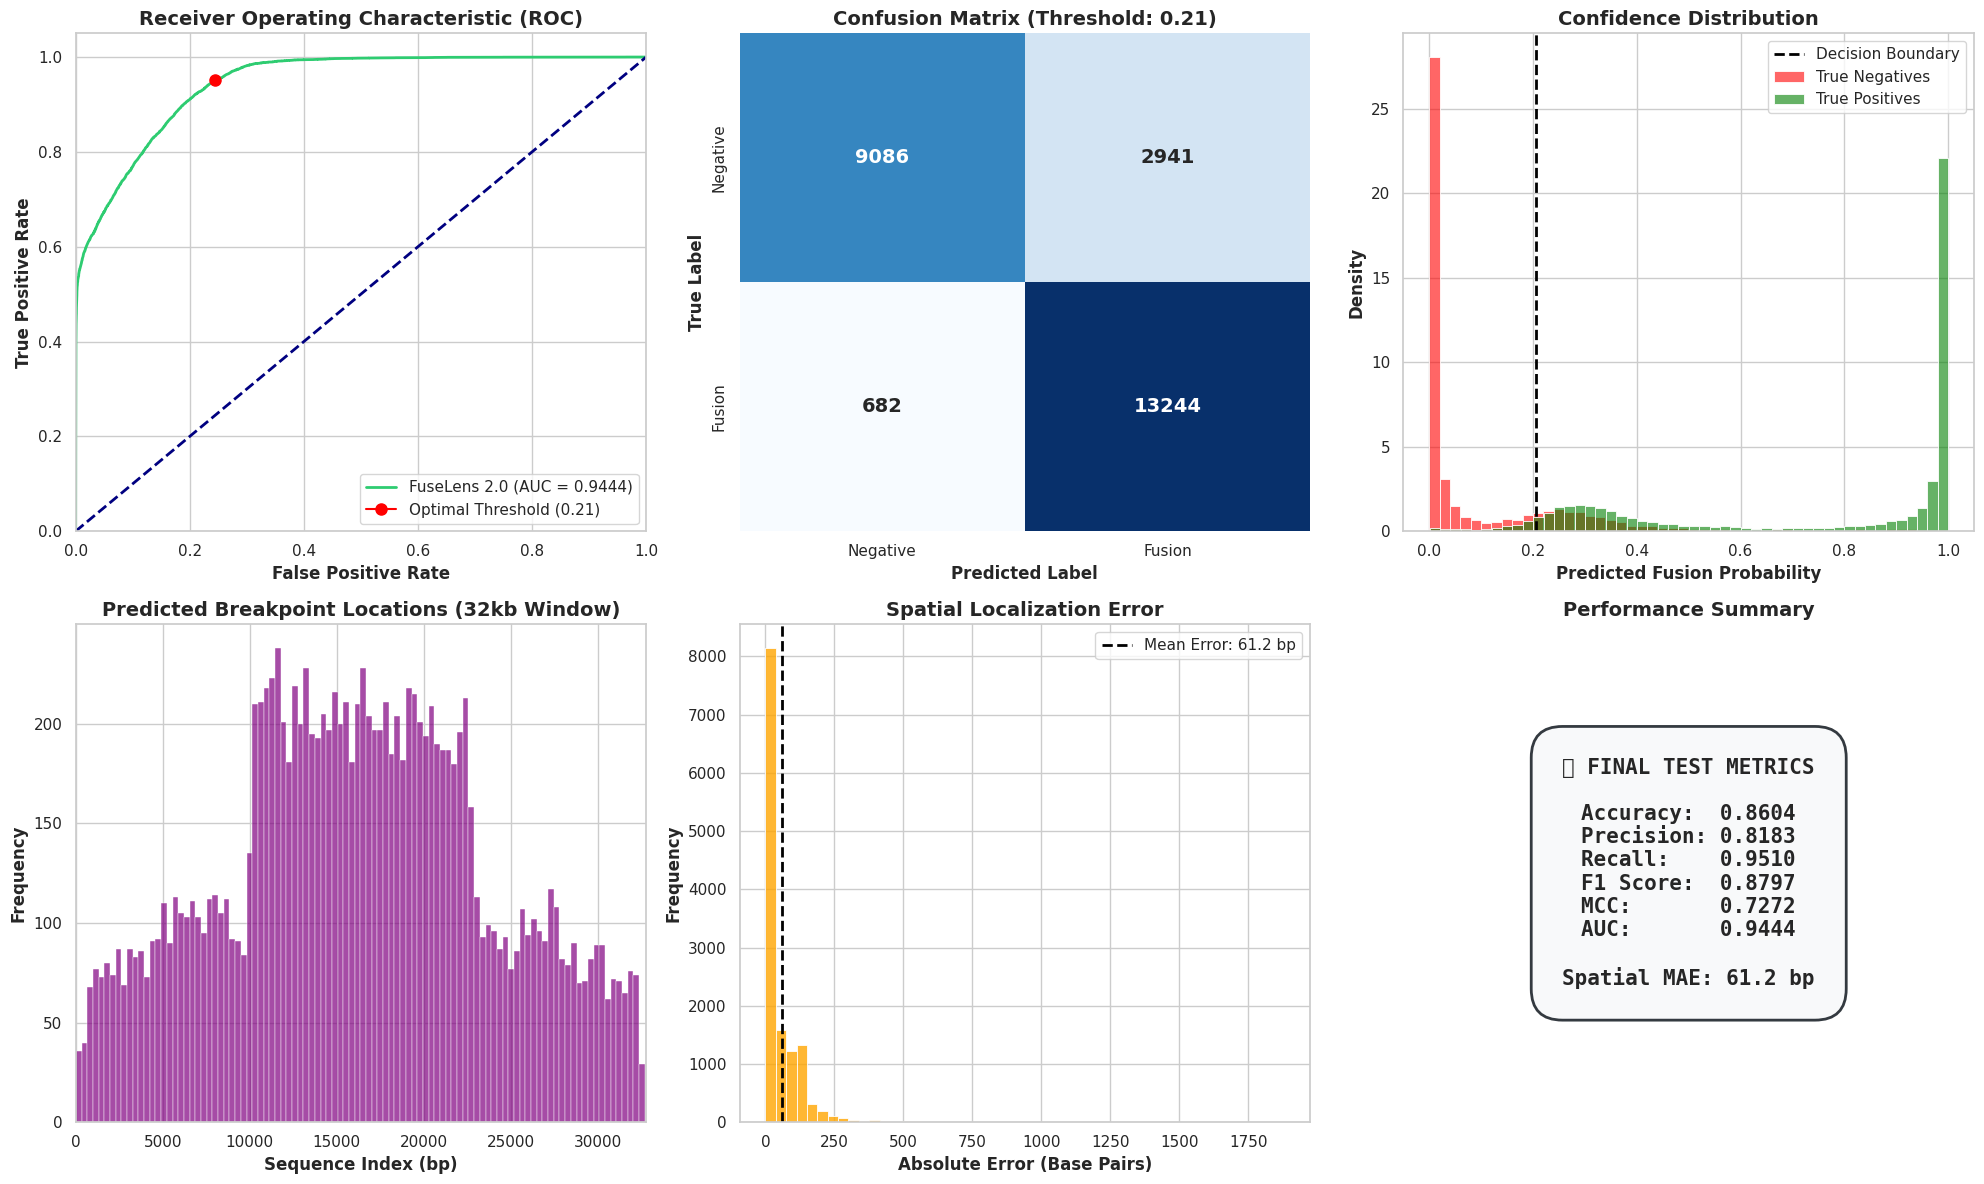

In [4]:
# ==============================================================================
# CELL 8: INFERENCE & VISUALIZATION (MULTI-TASK LEARNING)
# ==============================================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, matthews_corrcoef)
import torch
from safetensors.torch import load_file

print("\n🧪 Preparing architecture and loading safetensors checkpoint...")

# 1. Explicitly instantiate the empty model architecture first
# (This requires Cell 3 to have been run so HyenaDNAMultiTask is defined)
model = HyenaDNAMultiTask(Config.MODEL_NAME, bp_loss_weight=Config.BP_LOSS_WEIGHT).to(device)

# 2. Point to the saved weights directory
checkpoint_dir = Config.OUTPUT_DIR
model_path = os.path.join(checkpoint_dir, "best_model.safetensors")

if not os.path.exists(model_path):
    raise FileNotFoundError(f"Checkpoint not found at {model_path}. Please ensure training completed.")

# 3. Load the saved weights into the architecture
model.load_state_dict(load_file(model_path))
model.eval() # Set to evaluation mode

# 4. Run inference on the held-out test set to generate plotting arrays
# (This requires Cells 4 and 5 to have been run for test_loader and validate_epoch)
print("🧪 Evaluating Best Model on Held-Out Test Set to generate plots...")
test_mets, t_true, t_probs, t_pred_bp, t_true_bp = validate_epoch(model, test_loader, device, desc="Testing")

print("\n📊 Calculating Optimal Threshold and Generating Plots...")

# ---------------------------------------------------------
# DYNAMIC THRESHOLD CALIBRATION (Maximizing F1 Score)
# ---------------------------------------------------------
pos_probs = t_probs[:, 1]
fpr, tpr, thresholds = roc_curve(t_true, pos_probs)

best_f1 = 0
optimal_threshold = 0.5
optimal_idx = 0

# Scan all possible thresholds to find the absolute best balance between Precision and Recall
for i, thresh in enumerate(thresholds):
    # Skip extreme edge-case thresholds to prevent degenerate boundaries
    if thresh > 0.99 or thresh < 0.01: 
        continue
        
    temp_pred = (pos_probs >= thresh).astype(int)
    temp_f1 = f1_score(t_true, temp_pred, zero_division=0)
    
    if temp_f1 > best_f1:
        best_f1 = temp_f1
        optimal_threshold = thresh
        optimal_idx = i

print(f"✅ Optimal Decision Threshold (Max F1) Calibrated to: {optimal_threshold:.4f}")

# Extract hard predictions using the optimal balanced threshold
t_pred = (pos_probs >= optimal_threshold).astype(int)

# Calculate all comprehensive metrics for the summary panel
acc = accuracy_score(t_true, t_pred)
prec = precision_score(t_true, t_pred, zero_division=0)
rec = recall_score(t_true, t_pred, zero_division=0)
f1 = f1_score(t_true, t_pred, zero_division=0)
mcc = matthews_corrcoef(t_true, t_pred)
auc_val = roc_auc_score(t_true, pos_probs)

# Set up the plotting style
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(20, 12))

# --- Plot 1: ROC Curve ---
ax1 = plt.subplot(2, 3, 1)
ax1.plot(fpr, tpr, color='#2ecc71', lw=2, label=f'FuseLens 2.0 (AUC = {auc_val:.4f})')
# Plot a dot showing where the optimal threshold is on the curve
ax1.plot(fpr[optimal_idx], tpr[optimal_idx], marker='o', markersize=8, color="red", label=f"Optimal Threshold ({optimal_threshold:.2f})")
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontweight='bold')
ax1.set_ylabel('True Positive Rate', fontweight='bold')
ax1.set_title('Receiver Operating Characteristic (ROC)', fontweight='bold', fontsize=14)
ax1.legend(loc="lower right")

# --- Plot 2: Confusion Matrix ---
ax2 = plt.subplot(2, 3, 2)
cm = confusion_matrix(t_true, t_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False,
            xticklabels=['Negative', 'Fusion'], yticklabels=['Negative', 'Fusion'],
            annot_kws={"size": 14, "weight": "bold"})
ax2.set_xlabel('Predicted Label', fontweight='bold')
ax2.set_ylabel('True Label', fontweight='bold')
ax2.set_title(f'Confusion Matrix (Threshold: {optimal_threshold:.2f})', fontweight='bold', fontsize=14)

# --- Plot 3: Confidence Score Distribution ---
ax3 = plt.subplot(2, 3, 3)
sns.histplot(pos_probs[t_true == 0], bins=50, color='red', alpha=0.6, label='True Negatives', ax=ax3, stat='density')
sns.histplot(pos_probs[t_true == 1], bins=50, color='green', alpha=0.6, label='True Positives', ax=ax3, stat='density')
ax3.axvline(optimal_threshold, color='black', linestyle='dashed', linewidth=2, label='Decision Boundary')
ax3.set_xlabel('Predicted Fusion Probability', fontweight='bold')
ax3.set_ylabel('Density', fontweight='bold')
ax3.set_title('Confidence Distribution', fontweight='bold', fontsize=14)
ax3.legend()

# --- Plot 4: Attention Peak Location (Across the 32kb Window) ---
tp_mask = (t_true == 1) & (t_pred == 1) & (t_true_bp != -100)

ax4 = plt.subplot(2, 3, 4)
if tp_mask.sum() > 0:
    sns.histplot(t_pred_bp[tp_mask], bins=100, color='purple', alpha=0.7, ax=ax4)
    ax4.set_xlabel('Sequence Index (bp)', fontweight='bold')
    ax4.set_ylabel('Frequency', fontweight='bold')
    ax4.set_title('Predicted Breakpoint Locations (32kb Window)', fontweight='bold', fontsize=14)
    ax4.set_xlim([0, Config.MAX_LEN])
else:
    ax4.text(0.5, 0.5, 'No True Positives Available', ha='center', va='center')

# --- Plot 5: Spatial Localization Error (MAE Histogram) ---
ax5 = plt.subplot(2, 3, 5)
final_mae = 0.0
if tp_mask.sum() > 0:
    bp_errors = np.abs(t_pred_bp[tp_mask] - t_true_bp[tp_mask])
    final_mae = np.mean(bp_errors)
    
    # Clip the plot at 2000bp to make the histogram readable
    plot_limit = min(2000, max(bp_errors))
    
    sns.histplot(bp_errors[bp_errors <= plot_limit], bins=50, color='orange', alpha=0.8, ax=ax5)
    ax5.axvline(final_mae, color='black', linestyle='dashed', linewidth=2, 
                label=f'Mean Error: {final_mae:.1f} bp')
    ax5.set_xlabel('Absolute Error (Base Pairs)', fontweight='bold')
    ax5.set_ylabel('Frequency', fontweight='bold')
    ax5.set_title('Spatial Localization Error', fontweight='bold', fontsize=14)
    ax5.legend()
else:
    ax5.text(0.5, 0.5, 'No True Positives Available', ha='center', va='center')

# --- Plot 6: Comprehensive Metrics Summary ---
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')  # Hide the axes for a clean text box

metrics_text = (
    f"🏆 FINAL TEST METRICS\n\n"
    f"Accuracy:  {acc:.4f}\n"
    f"Precision: {prec:.4f}\n"
    f"Recall:    {rec:.4f}\n"
    f"F1 Score:  {f1:.4f}\n"
    f"MCC:       {mcc:.4f}\n"
    f"AUC:       {auc_val:.4f}\n\n"
    f"Spatial MAE: {final_mae:.1f} bp"
)

# Render a styled bounding box for the metrics
ax6.text(0.5, 0.5, metrics_text, ha='center', va='center', fontsize=15, 
         fontfamily='monospace', fontweight='bold', 
         bbox=dict(boxstyle="round,pad=1.5", facecolor="#f8f9fa", edgecolor="#343a40", lw=2))
ax6.set_title('Performance Summary', fontweight='bold', fontsize=14)

# Save and Show
plt.tight_layout()
plot_path = os.path.join(checkpoint_dir, "fuselens2_mtl_evaluation_plots.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✅ Plots successfully saved to: {plot_path}")
plt.show()